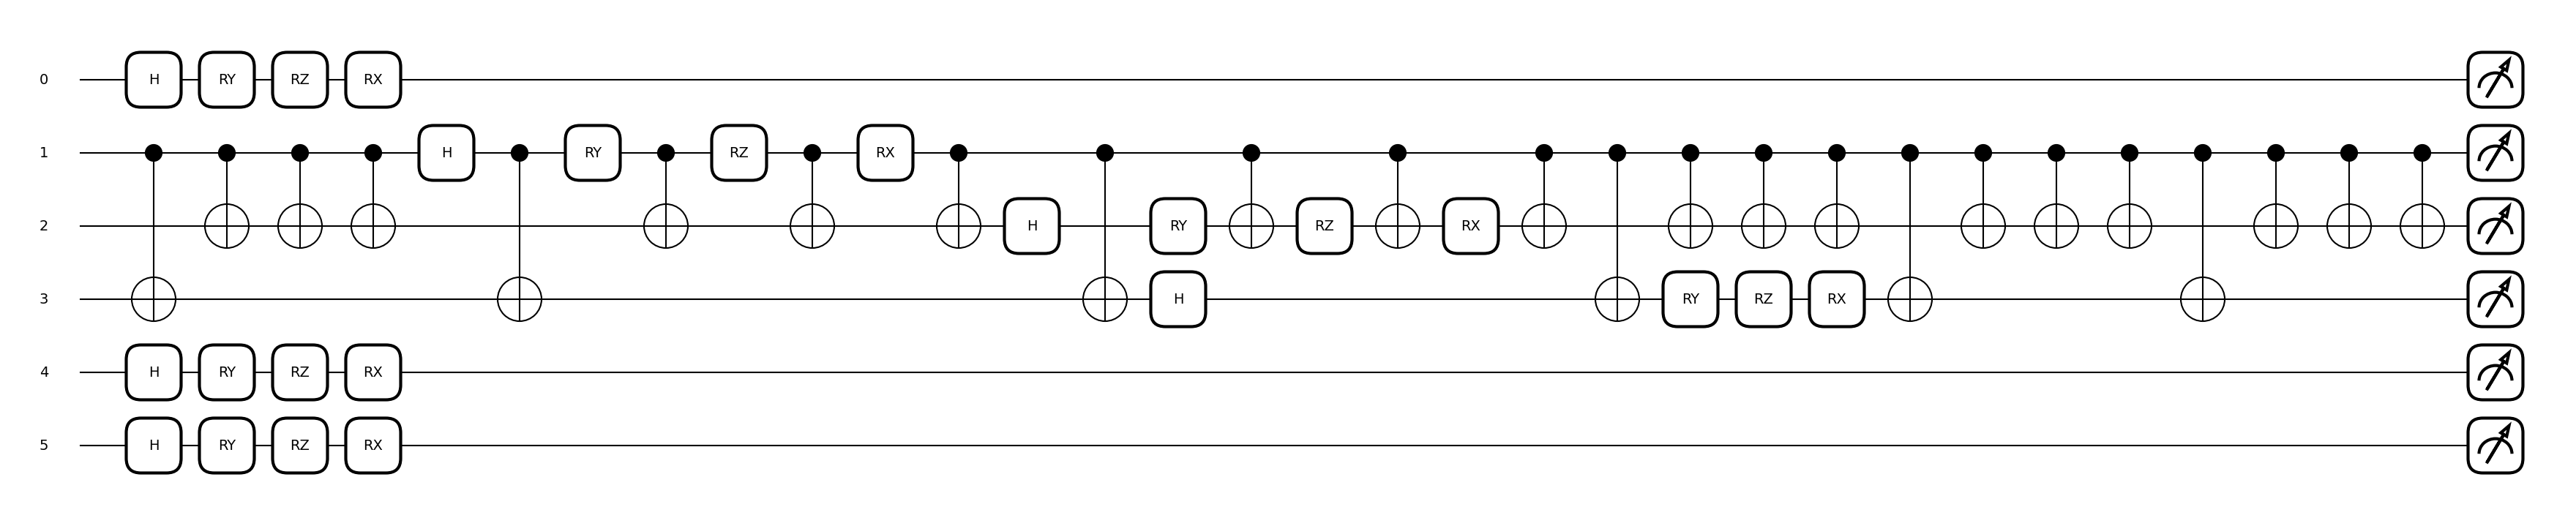

In [1]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Sample training data
import lightgbm as lgb
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from sklearn.svm import SVR


df=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\1002-ORIGIN-2D electronic properties2.csv",encoding='ISO-8859–1')      
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y = df['Band gap ']

# defining target
x=df[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]



# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x)

# Quantum setup
n_qubits = 6
dev = qml.device("default.qubit", wires=n_qubits)

# Define quantum feature map
def quantum_feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.CNOT(wires=[1, 3])
        qml.RY(np.pi,wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RZ(x[i % len(x)], wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RX(np.pi*1.5, wires=i)
        qml.CNOT(wires=[1, 2])

# Define a quantum node
@qml.qnode(dev)
def circuit(x):
    quantum_feature_map(x)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

# Visualize the quantum circuit for a sample
sample_x = X_train_scaled[0][:n_qubits]  # Take the first training sample, limit to `n_qubits`

# Draw the circuit using matplotlib
fig, ax = qml.draw_mpl(circuit)(sample_x)
plt.show()


In [2]:
y_train=(y)

In [3]:
# Quantum kernel function
@qml.qnode(dev)
def quantum_kernel(x1, x2):
    quantum_feature_map(x1)
    qml.adjoint(quantum_feature_map)(x2)
    return qml.probs(wires=range(n_qubits))
# Compute the kernel matrix for input data
def compute_kernel_matrix(X):
    n_samples = len(X)
    kernel_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(n_samples):
            # Directly access the probability value (first element)
            kernel_matrix[i, j] = quantum_kernel(X[i], X[j])[0]
    return kernel_matrix
# Compute the quantum kernel matrix for training
K_train = compute_kernel_matrix(X_train_scaled)

# Train the SVR with a precomputed kernel matrix
svr = SVR(kernel='precomputed', epsilon=0.07491851902055541,C=977,gamma=2.0881963569756823)
svr.fit(K_train, y_train)



,kernel,'precomputed'
,degree,3
,gamma,2.0881963569756823
,coef0,0.0
,tol,0.001
,C,977
,epsilon,0.07491851902055541
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


train r^2: 0.995364822104264
train MAE 0.05751896719011849
train RMSE: 0.09395727815752627


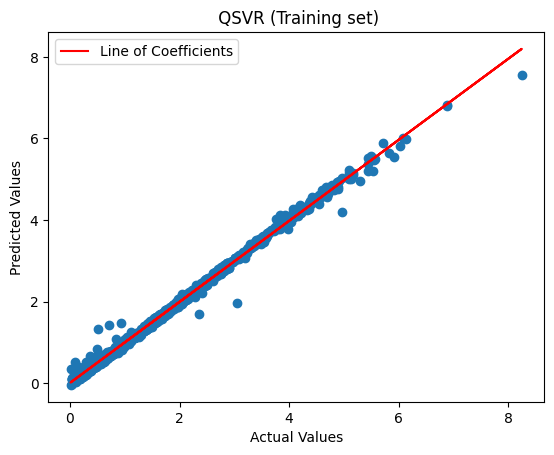

In [4]:
y_predtrain= svr.predict(K_train)
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
print('train r^2:',r2_score(y_train,y_predtrain))
print('train MAE', mean_absolute_error(y_train,y_predtrain))
print('train RMSE:',np.sqrt(mean_squared_error(y_train,y_predtrain)))
# Plot straight line
plt.scatter(y_train,y_predtrain)
coefficients = np.polyfit(y_train,y_predtrain, 1)
line = np.polyval(coefficients, y_train)
plt.plot(y_train, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_train, line, color='r',)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y_train,y_predtrain)), (-0.2, 20.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y_train,y_predtrain)), (-0.2, 18.2))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y_train,y_predtrain))), (-0.2, 16.0))
plt.title(" QSVR (Training set)")#title
plt.legend()

In [5]:
df_true50=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-50-EXTERNAL DATA.csv",encoding='ISO-8859–1')    
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y2 = df_true50['Band gap ']

# defining target
x2=df_true50[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test2= scaler.transform(x2)

# Compute the test kernel matrix (train-test kernel)
K_test2 = np.zeros((len(x_test2), len(X_train_scaled)))
for i in range(len(x_test2)):
    for j in range(len(X_train_scaled)):
        K_test2[i, j] = quantum_kernel(x_test2[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred2 = svr.predict(K_test2)
print("Predicted values:", y_pred2)

Predicted values: [1.53776338 1.35460908 1.15463389 0.45756678 1.84783938 1.38507275
 1.06945156 0.43907966 2.93172869 3.01369362 0.01540866 5.05331536
 2.40123935 0.35671568 1.29578105 0.43537066 0.25741378 3.32228639
 0.32392412 2.98940674 1.09664679 2.6502268  0.68985868 2.85692166
 2.02177623 0.81526602 2.20597455 1.60712254 2.30383371 2.46771931
 3.44011234 0.36319447 0.90865214 0.88565184 1.43961283 1.38561832
 0.17105949 4.35321706 3.32834173 0.35870625 2.77821282 4.13453545
 0.72464416 0.3502271  0.68029927 0.81185874 1.44018066 2.44241406
 1.46313622 4.68024653]


Model evaluation - Test Set:
r^2: 0.9744928112373314
MAE 0.09891835458677681
RMSE: 0.20151266246371552


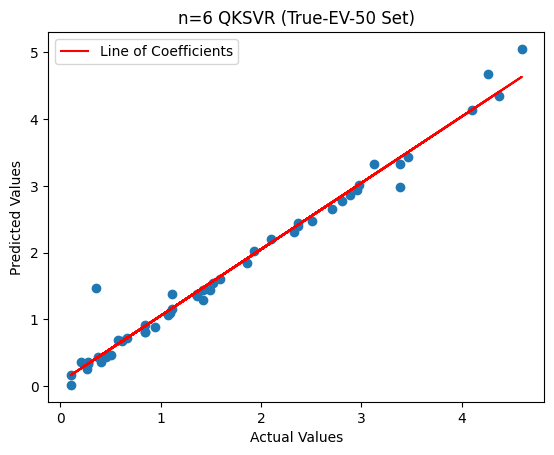

In [15]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y2, y_pred2))
print('MAE', mean_absolute_error(y2, y_pred2))
print('RMSE:',np.sqrt(mean_squared_error(y2, y_pred2)))
# Plot straight line
plt.scatter(y2, y_pred2)
coefficients = np.polyfit(y2, y_pred2, 1)
line = np.polyval(coefficients, y2)
plt.plot(y2, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y2, y_pred2)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y2, y_pred2))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y2, y_pred2)), (-0.2, 13.2))
plt.title("n=6 QKSVR (True-EV-50 Set)")#title
plt.legend()

In [9]:
df3=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-100-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y3 = df3['Band gap ']

# defining target
x3=df3[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test3= scaler.transform(x3)

# Compute the test kernel matrix (train-test kernel)
K_test3 = np.zeros((len(x_test3), len(X_train_scaled)))
for i in range(len(x_test3)):
    for j in range(len(X_train_scaled)):
        K_test3[i, j] = quantum_kernel(x_test3[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred3 = svr.predict(K_test3)
print("Predicted values:", y_pred3)

Predicted values: [ 2.86838614  4.87039497  3.93759161  1.41398311  5.16491514  2.94830196
  5.97027064  1.80315121  0.76081744  0.36892858  0.22479496  0.56578301
  0.38895251  0.34811313  0.06686637  2.27022902  0.48926525  0.55090926
  2.03494817  2.32152422  2.64741584  0.16669028  0.97908419  1.04791775
  0.73509288  0.87503666  3.902153    5.38707985  2.03241265  2.61976914
  4.0562414   5.59258618  4.20982517  1.81959271  1.94221242 -0.06560669
  0.89545281  1.49190048  0.9556485   3.53772291  1.02332491  0.86056714
  0.49593941  1.26534302  2.13986803  1.4261673   1.39108749  0.15736717
  0.96743799  1.71674881  0.53095022  0.66130975  0.13778972  0.66030059
  0.2641968   1.3043796   2.42621066  1.01290527  0.8940724   5.873939
  5.91083505  0.90955662  1.10392136  1.93986754  1.54623655  2.61033535
  4.63065483  1.95459189  1.50890213  3.47975613  0.46536476  3.9323248
  1.13609139  2.05939604  0.87199335  4.65339715  2.7844697   0.83917626
  1.79084557  1.20324818  0.68358799

Model evaluation - Test Set:
r^2: 0.9948042814841688
MAE 0.07297290395361948
RMSE: 0.1143132906200989


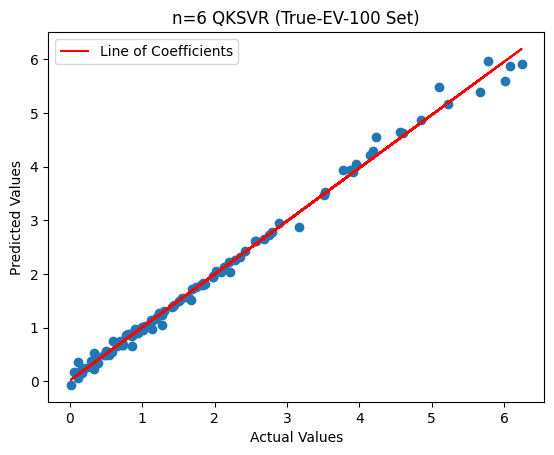

In [10]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y3, y_pred3))
print('MAE', mean_absolute_error(y3, y_pred3))
print('RMSE:',np.sqrt(mean_squared_error(y3, y_pred3)))
# Plot straight line
plt.scatter(y3, y_pred3)
coefficients = np.polyfit(y3, y_pred3, 1)
line = np.polyval(coefficients, y3)
plt.plot(y3, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y3, y_pred3)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y3, y_pred3))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y3, y_pred3)), (-0.2, 13.2))
plt.title("n=6 QKSVR (True-EV-100 Set)")#title
plt.legend()

In [11]:

df4=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-250-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y4 = df4['Band gap ']

# defining target
x4=df4[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test4= scaler.transform(x4)

# Compute the test kernel matrix (train-test kernel)
K_test4 = np.zeros((len(x_test4), len(X_train_scaled)))
for i in range(len(x_test4)):
    for j in range(len(X_train_scaled)):
        K_test4[i, j] = quantum_kernel(x_test4[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred4 = svr.predict(K_test4)
print("Predicted values:", y_pred4)

Predicted values: [1.11466469e+00 4.89566101e+00 3.27134332e+00 6.48749182e-01
 3.23198912e+00 2.34836021e+00 2.70725604e+00 7.99757823e-01
 7.89896557e-01 6.14680193e+00 3.11507004e-01 5.20646613e+00
 3.28543887e+00 3.55692009e-01 2.23136736e-01 1.72236324e-01
 4.56897121e+00 6.48198387e-01 4.29948830e-01 2.97441014e+00
 4.24142465e+00 1.18932326e-01 7.14399375e+00 1.34571662e+00
 9.22401685e-01 8.54422119e-01 3.16107726e+00 2.48952523e+00
 2.03284004e+00 1.71896067e+00 1.07845211e+00 9.52275581e-01
 7.26786257e-01 7.27090237e-01 6.66874368e-01 1.56842121e+00
 7.37572638e-01 1.31919052e+00 1.70806125e+00 3.40683532e+00
 8.40878749e-01 9.15548246e-01 4.20348333e-01 9.28563529e-01
 8.38093481e-01 3.91850907e+00 4.40909268e-01 8.92957838e-01
 1.63207515e+00 7.42644904e-01 4.57473338e-01 1.46486185e+00
 5.11196864e-01 7.76807301e-01 8.29094077e-01 2.06886687e+00
 4.15933833e-01 8.66816355e-01 7.88548377e-01 1.27230069e+00
 7.21254998e-01 8.39601527e-01 2.36740108e+00 6.76989104e-01
 6.802

Model evaluation - Test Set:
r^2: 0.9818613174674409
MAE 0.08898716020191515
RMSE: 0.19702064283891324


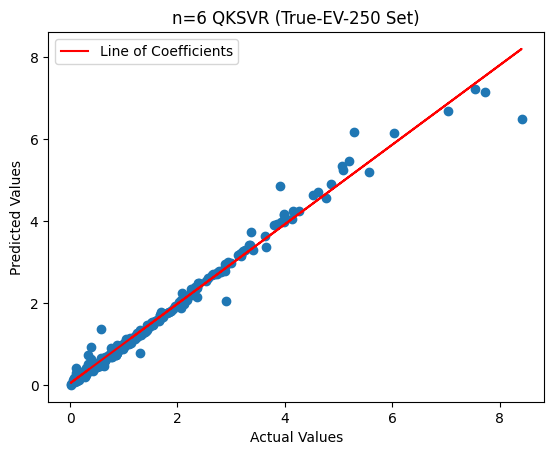

In [12]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y4, y_pred4))
print('MAE', mean_absolute_error(y4, y_pred4))
print('RMSE:',np.sqrt(mean_squared_error(y4, y_pred4)))
# Plot straight line
plt.scatter(y4, y_pred4)
coefficients = np.polyfit(y4, y_pred4, 1)
line = np.polyval(coefficients, y4)
plt.plot(y4, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y4, y_pred4)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y4, y_pred4))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y4, y_pred4)), (-0.2, 13.2))
plt.title("n=6 QKSVR (True-EV-250 Set)")#title
plt.legend()

In [13]:
df5=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-400-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y5 = df5['Band gap ']

# defining target
x5=df5[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test5= scaler.transform(x5)

# Compute the test kernel matrix (train-test kernel)
K_test5 = np.zeros((len(x_test5), len(X_train_scaled)))
for i in range(len(x_test5)):
    for j in range(len(X_train_scaled)):
        K_test5[i, j] = quantum_kernel(x_test5[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred5 = svr.predict(K_test5)
print("Predicted values:", y_pred5)

Predicted values: [ 1.53776338e+00  1.35460908e+00  1.15463389e+00  4.57566782e-01
  1.84783938e+00  1.38507275e+00  1.06945156e+00  4.39079661e-01
  2.93172869e+00  3.01369362e+00  1.54086555e-02  5.05331536e+00
  2.40123935e+00  3.56715678e-01  1.29578105e+00  4.35370661e-01
  2.57413776e-01  3.32228639e+00  3.23924121e-01  2.98940674e+00
  1.09664679e+00  2.65022680e+00  6.89858684e-01  2.85692166e+00
  2.02177623e+00  8.15266017e-01  2.20597455e+00  1.60712254e+00
  2.30383371e+00  2.46771931e+00  3.44011234e+00  3.63194465e-01
  9.08652141e-01  8.85651837e-01  1.43961283e+00  1.38561832e+00
  1.71059494e-01  4.35321706e+00  3.32834173e+00  3.58706247e-01
  2.77821282e+00  4.13453545e+00  7.24644163e-01  3.50227101e-01
  6.80299267e-01  8.11858739e-01  1.44018066e+00  2.44241406e+00
  1.46313622e+00  4.68024653e+00  2.86838614e+00  4.87039497e+00
  3.93759161e+00  1.41398311e+00  5.16491514e+00  2.94830196e+00
  5.97027064e+00  1.80315121e+00  7.60817440e-01  3.68928585e-01
  2.247

Model evaluation - Test Set:
r^2: 0.9850097695020088
MAE 0.08622499543794893
RMSE: 0.18056442011138946


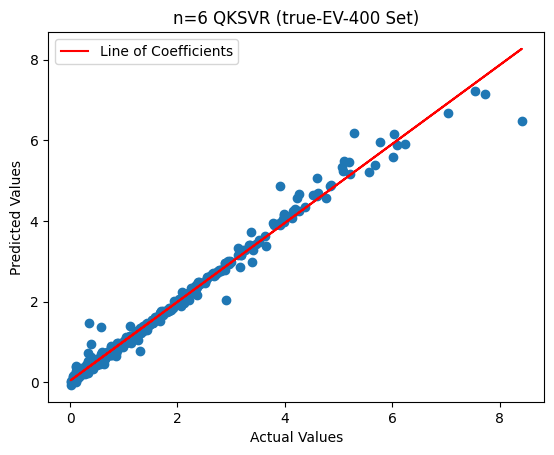

In [14]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y5, y_pred5))
print('MAE', mean_absolute_error(y5, y_pred5))
print('RMSE:',np.sqrt(mean_squared_error(y5, y_pred5)))
# Plot straight line
plt.scatter(y5, y_pred5)
coefficients = np.polyfit(y5, y_pred5, 1)
line = np.polyval(coefficients, y5)
plt.plot(y5, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y5, y_pred5)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y5, y_pred5))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y5, y_pred5)), (-0.2, 13.2))
plt.title("n=6 QKSVR (true-EV-400 Set)")#title
plt.legend()